## **Intersection over Union (IoU)**

### **Definition**

**Intersection over Union (IoU)** is a key metric used to evaluate the performance of object detection algorithms. It measures the overlap between two bounding boxes:
- The **predicted bounding box** (output from the model), and
- The **ground truth bounding box** (from annotated data).

It provides a single scalar value that reflects how closely the predicted box aligns with the actual object.

---

### **Interpretation**

| IoU Value | Interpretation                    |
|-----------|------------------------------------|
| 1.0       | Perfect overlap (ideal match)      |
| 0.0       | No overlap                         |
| ~0.5      | Partial overlap (acceptable range) |
| < 0.5     | Often considered a poor prediction |

In evaluation tasks, predictions are usually counted as **true positives** if their IoU with a ground truth box exceeds a specific threshold (e.g., **0.5**).

---

### **Usage in Evaluation Benchmarks**

- **PASCAL VOC**:
  - Uses a **fixed IoU threshold of 0.5** to determine if a prediction is a true positive.
  - mAP (mean Average Precision) is calculated using this threshold.

- **MS COCO**:
  - Evaluates model performance over **multiple IoU thresholds**: from 0.5 to 0.95 in steps of 0.05.
  - This gives a more comprehensive performance metric and penalizes models that are only accurate at lower thresholds.

---

### **Applications of IoU**

- Object Detection (e.g., YOLO, Faster R-CNN)
- Instance Segmentation
- Bounding box regression training loss functions
- Non-Maximum Suppression (NMS)

---


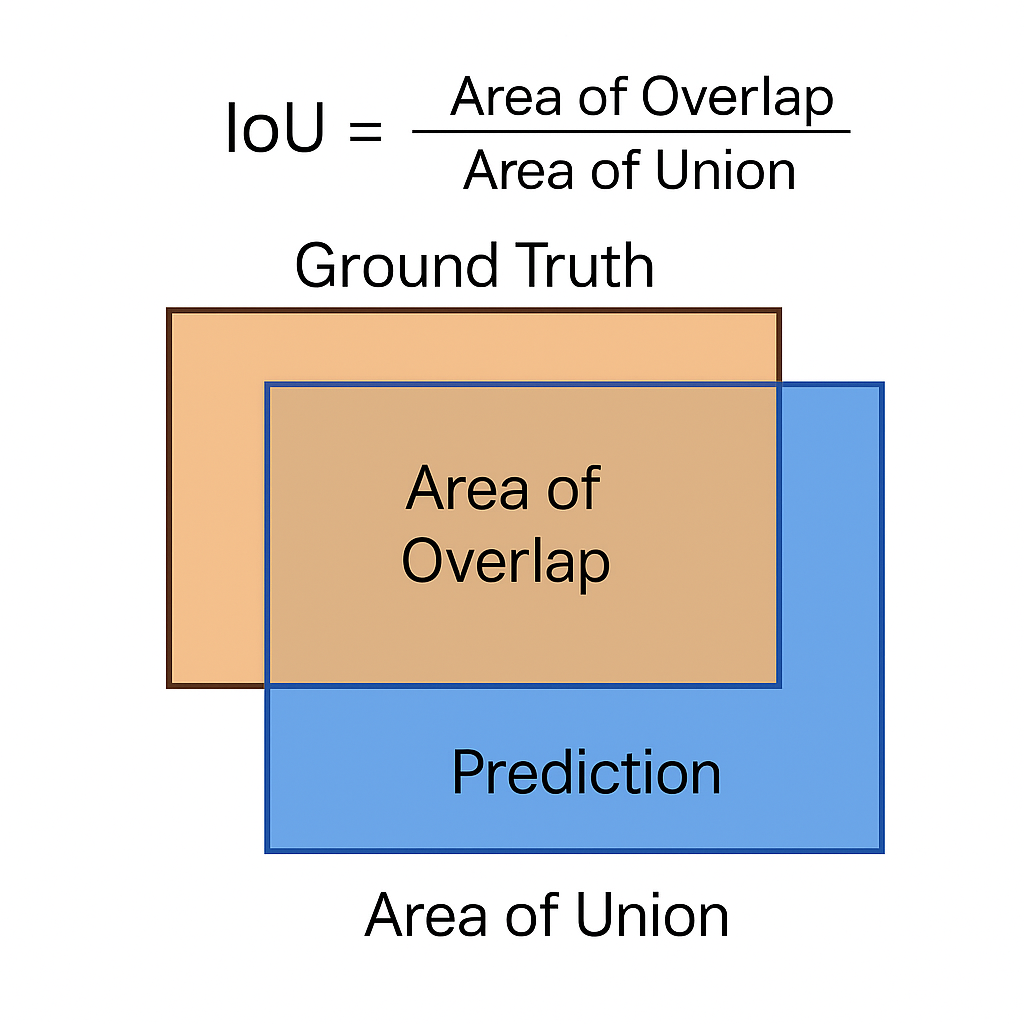

In [1]:
def get_iou(boxA, boxB, epsilon=1e-5):  # Consider boxA as the ground truth bounding box and boxB as the region proposal and epsilon parameter id defined to address the issue of zero division error
    x1 = max(boxA[0], boxB[0])
    y1 = max(boxA[1], boxB[1])
    x2 = min(boxA[2], boxB[2])
    y2 = min(boxA[3], boxB[3])
    width = (x2 - x1)
    height = (y2 - y1)
    if (width<0) or (height <0):
        return 0.0
    area_overlap = width * height
    area_a = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    area_b = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])
    area_combined = area_a + area_b - area_overlap
    iou = area_overlap / (area_combined+epsilon)
    return iou